# Food Delivery Delay and Rating Analysis

## 13-Step Notebook Flow
1. Define objective and scope.
2. Load required libraries and source data.
3. Inspect schema and missing values.
4. Rename columns and clean data.
5. Engineer delay and time features.
6. Compute key KPIs.
7. Create visualizations (inline only).
8. Platform and category analysis.
9. Time-based analysis (orders/hour and delay/hour).
10. Product category and order value vs rating analysis.
11. Extended refund analysis.
12. Baseline ML model for rating prediction.
13. Recommendations and limitations.

Note: This notebook assumes the current dataset has rating and refund columns.

### Step 1

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
BASE_DIR = Path.cwd()
RAW_FILE = BASE_DIR / "Ecommerce_Delivery_Analytics_New.csv"

df = pd.read_csv(RAW_FILE)
print("Raw shape:", df.shape)
df.head()

Raw shape: (100000, 11)


,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No


### Step 2
This cell imports required libraries, sets plotting style, loads the source CSV, and previews the raw data shape and sample rows to verify successful ingestion.

In [3]:
print("Columns:")
print(df.columns.tolist())

missing = df.isna().sum().sort_values(ascending=False)
missing.head(10)

Columns:
['Order ID', 'Customer ID', 'Platform', 'Order Date & Time', 'Delivery Time (Minutes)', 'Product Category', 'Order Value (INR)', 'Customer Feedback', 'Service Rating', 'Delivery Delay', 'Refund Requested']


Order ID                   0
Customer ID                0
Platform                   0
Order Date & Time          0
Delivery Time (Minutes)    0
Product Category           0
Order Value (INR)          0
Customer Feedback          0
Service Rating             0
Delivery Delay             0
dtype: int64

### Step 3
This step inspects the dataset schema and missing-value profile so we can identify potential quality issues before transformation.

In [4]:
COLUMN_MAP = {
    "Order ID": "order_id",
    "Customer ID": "customer_id",
    "Platform": "platform",
    "Order Date & Time": "order_time_raw",
    "Delivery Time (Minutes)": "delivery_duration_min",
    "Product Category": "product_category",
    "Order Value (INR)": "order_value_inr",
    "Customer Feedback": "customer_feedback",
    "Service Rating": "rating",
    "Delivery Delay": "delivery_delay",
    "Refund Requested": "refund_requested",
}

cleaned = df.rename(columns=COLUMN_MAP).copy()
cleaned["order_id"] = cleaned["order_id"].astype("string").str.strip()
cleaned = cleaned.drop_duplicates(subset=["order_id"], keep="first")

for col in ["delivery_duration_min", "order_value_inr", "rating"]:
    if col in cleaned.columns:
        cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

cleaned.head()

,order_id,customer_id,platform,order_time_raw,delivery_duration_min,product_category,order_value_inr,customer_feedback,rating,delivery_delay,refund_requested
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No


### Step 4
This cell standardizes column names, removes duplicate order records, and converts key measures to numeric format for reliable analysis.

In [5]:
time_like = "00:" + cleaned["order_time_raw"].astype("string").str.strip()
cleaned["order_minute_of_day"] = pd.to_timedelta(time_like, errors="coerce").dt.total_seconds() / 60
cleaned["order_hour"] = np.floor(cleaned["order_minute_of_day"] / 60).astype("Int64")

cleaned["delivery_delay"] = cleaned["delivery_delay"].astype("string").str.strip().str.title()
cleaned["refund_requested"] = cleaned["refund_requested"].astype("string").str.strip().str.title()
cleaned["delay_category"] = np.where(cleaned["delivery_duration_min"] > 30, "Late", "On-Time")
cleaned.loc[cleaned["delivery_delay"] == "Yes", "delay_category"] = "Late"

required_cols = ["order_id", "delivery_duration_min", "platform", "product_category"]
if "rating" in cleaned.columns:
    required_cols.append("rating")
cleaned = cleaned.dropna(subset=required_cols)

print("Cleaned shape:", cleaned.shape)
cleaned.head()

Cleaned shape: (100000, 14)


,order_id,customer_id,platform,order_time_raw,delivery_duration_min,product_category,order_value_inr,customer_feedback,rating,delivery_delay,refund_requested,order_minute_of_day,order_hour,delay_category
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No,19.491667,0,On-Time
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No,54.491667,0,On-Time
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes,21.491667,0,On-Time
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes,19.491667,0,Late
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No,49.491667,0,On-Time


### Step 5
This step creates time-based and delay-based features, normalizes categorical flags, and filters records so only valid rows continue into KPI and chart steps.

In [6]:
late_mask = cleaned["delay_category"].eq("Late")
summary = {
    "orders_analyzed": int(len(cleaned)),
    "average_delivery_minutes": float(cleaned["delivery_duration_min"].mean()),
    "late_share_pct": float(late_mask.mean() * 100),
}

if "rating" in cleaned.columns and cleaned["rating"].notna().any():
    summary.update({
        "average_rating": float(cleaned["rating"].mean()),
        "avg_rating_on_time": float(cleaned.loc[~late_mask, "rating"].mean()),
        "avg_rating_late": float(cleaned.loc[late_mask, "rating"].mean()),
        "duration_rating_corr": float(cleaned[["delivery_duration_min", "rating"]].corr().iloc[0, 1]),
    })

summary

{'orders_analyzed': 100000,
 'average_delivery_minutes': 29.53614,
 'late_share_pct': 46.165,
 'average_rating': 3.24079,
 'avg_rating_on_time': 3.2427417107829477,
 'avg_rating_late': 3.238514025777104,
 'duration_rating_corr': 0.00013589581726302746}

### Step 6
This cell calculates primary metrics for delivery performance and customer rating impact. Rating metrics are included only when rating data exists.

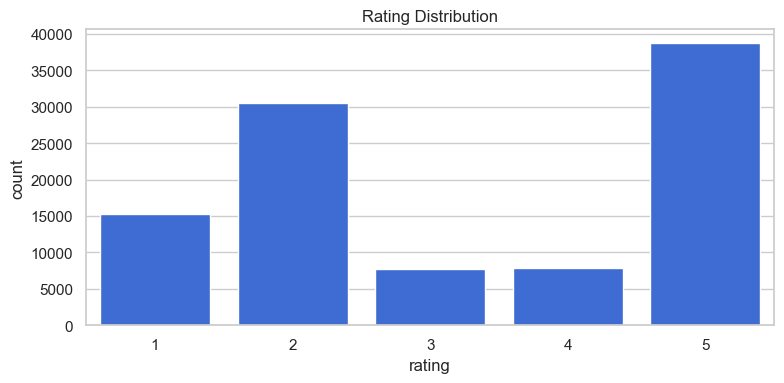

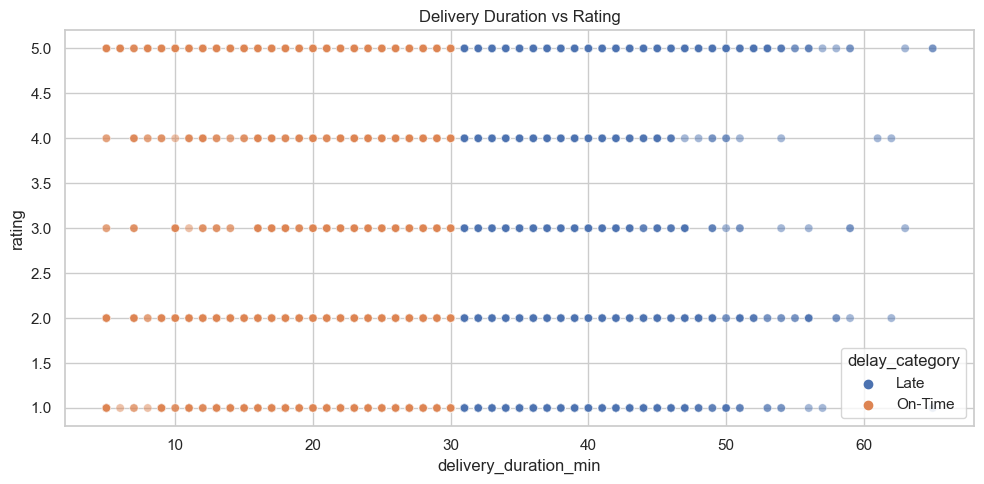

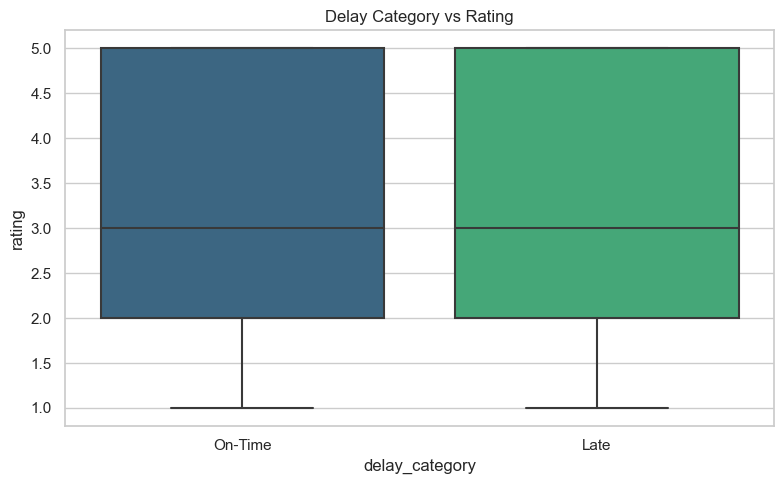

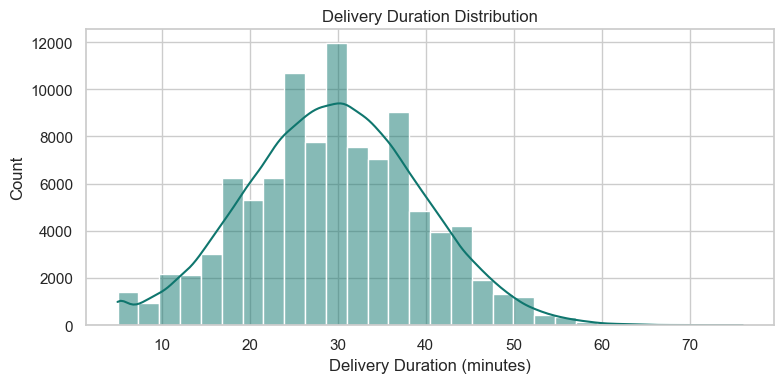

In [7]:
# Step 7: Visualizations are rendered inline only. No files are saved.
if "rating" in cleaned.columns and cleaned["rating"].notna().any():
    plt.figure(figsize=(8, 4))
    sns.countplot(data=cleaned, x="rating", order=sorted(cleaned["rating"].dropna().unique()), color="#2563eb")
    plt.title("Rating Distribution")
    plt.tight_layout()
    plt.show()

    sample = cleaned.sample(min(len(cleaned), 5000), random_state=42)
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=sample, x="delivery_duration_min", y="rating", hue="delay_category", alpha=0.5)
    plt.title("Delivery Duration vs Rating")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=cleaned, x="delay_category", y="rating", order=["On-Time", "Late"], palette="viridis")
    plt.title("Delay Category vs Rating")
    plt.tight_layout()
    plt.show()
else:
    print("Rating column is missing or empty. Rating-based visualizations are skipped.")

plt.figure(figsize=(8, 4))
sns.histplot(cleaned["delivery_duration_min"], bins=30, kde=True, color="#0f766e")
plt.title("Delivery Duration Distribution")
plt.xlabel("Delivery Duration (minutes)")
plt.tight_layout()
plt.show()

### Step 7
This section renders inline charts for rating patterns and delivery-duration behavior. Charts are displayed inside the notebook and are not saved to any folder.

### Step 8
This cell adds operational comparison visuals for hour-based delivery performance, platform late-share, and variable correlations to support decision-making.

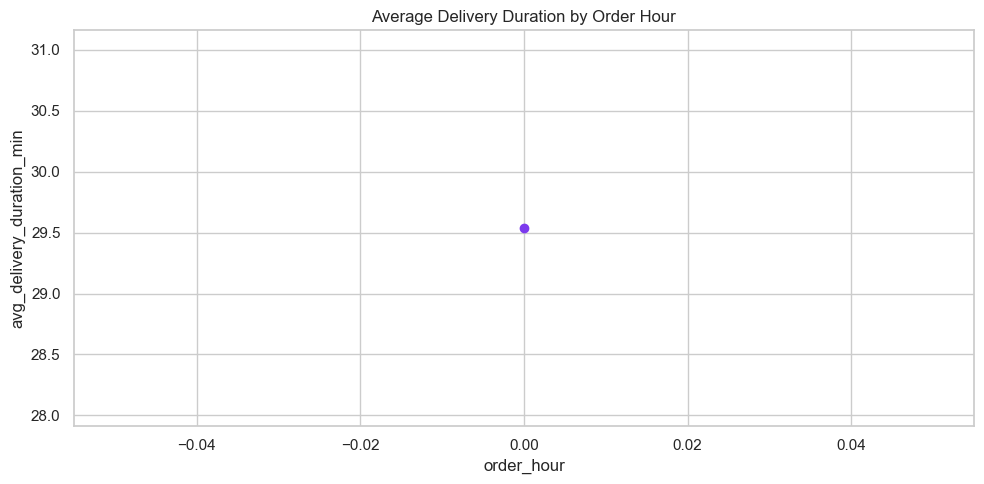

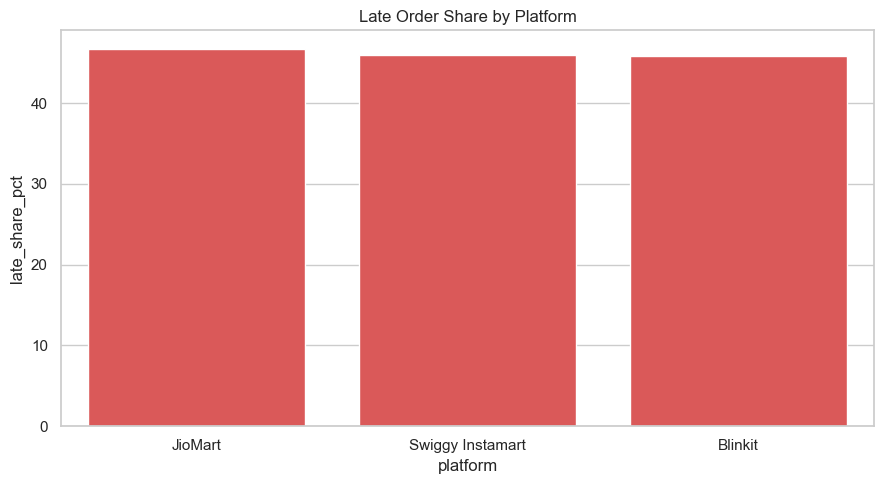

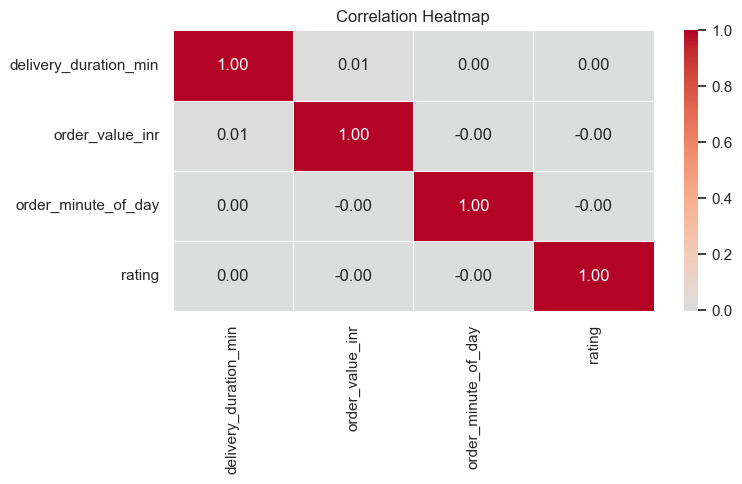

In [8]:
hour_summary = cleaned.groupby("order_hour", dropna=True)["delivery_duration_min"].mean().reset_index()
hour_summary["order_hour"] = pd.to_numeric(hour_summary["order_hour"], errors="coerce")
hour_summary["delivery_duration_min"] = pd.to_numeric(hour_summary["delivery_duration_min"], errors="coerce")
hour_summary = hour_summary.dropna().sort_values("order_hour")

plt.figure(figsize=(10, 5))
plt.plot(hour_summary["order_hour"], hour_summary["delivery_duration_min"], marker="o", color="#7c3aed")
plt.title("Average Delivery Duration by Order Hour")
plt.xlabel("order_hour")
plt.ylabel("avg_delivery_duration_min")
plt.tight_layout()
plt.show()

delay_share = (
    cleaned.assign(is_late=cleaned["delay_category"].eq("Late").astype(int))
    .groupby("platform", dropna=False)["is_late"]
    .mean()
    .mul(100)
    .reset_index(name="late_share_pct")
    .sort_values("late_share_pct", ascending=False)
)
plt.figure(figsize=(9, 5))
sns.barplot(data=delay_share, x="platform", y="late_share_pct", color="#ef4444")
plt.title("Late Order Share by Platform")
plt.tight_layout()
plt.show()

corr_cols = ["delivery_duration_min", "order_value_inr", "order_minute_of_day"]
if "rating" in cleaned.columns and cleaned["rating"].notna().any():
    corr_cols.append("rating")
corr = cleaned[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Step 9
Time-Based Analysis: orders per hour and average delay per hour to identify peak load and peak delay windows.

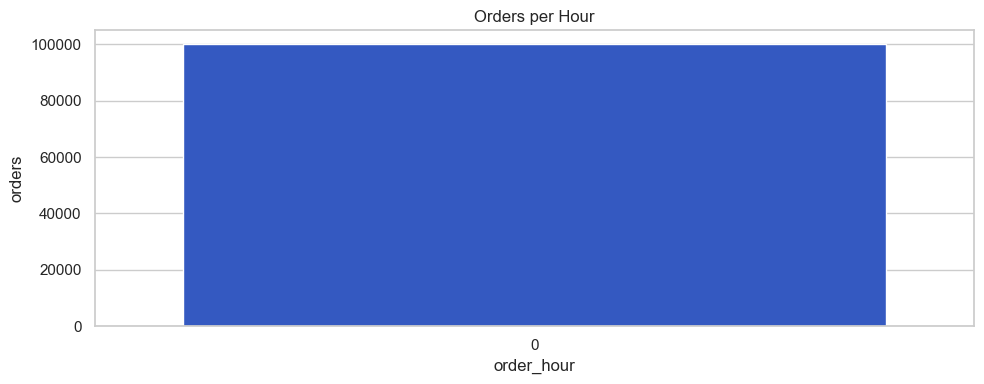

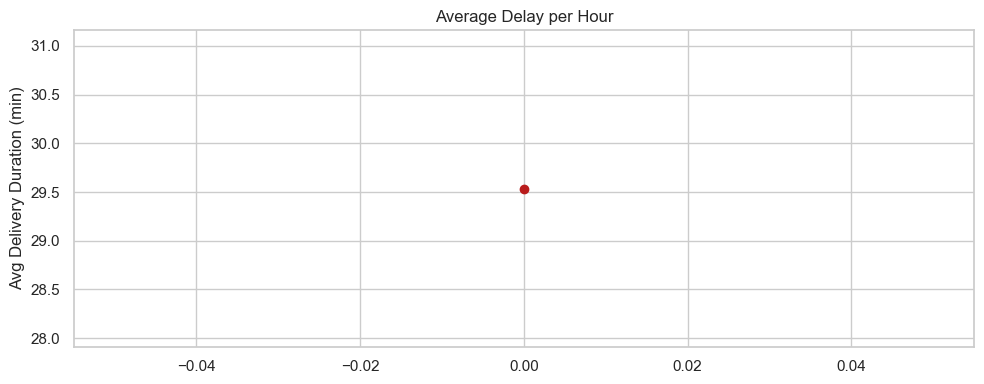

Peak delays happen around 00:00
Note: source order time appears minute-second formatted, so hour-level spread is limited.


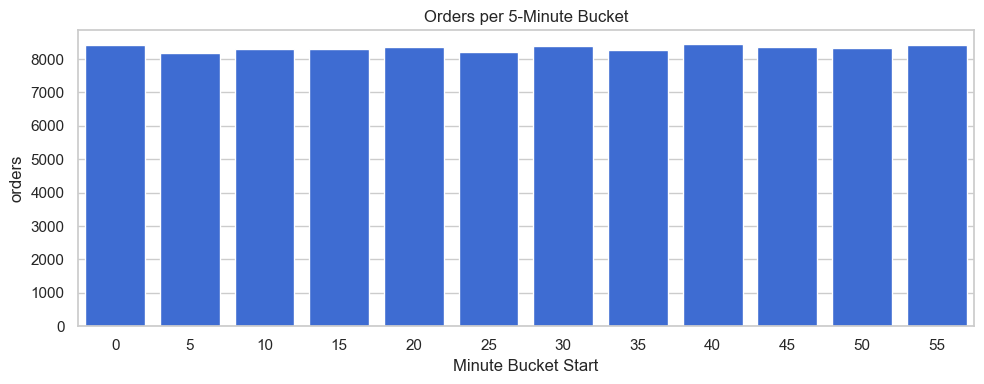

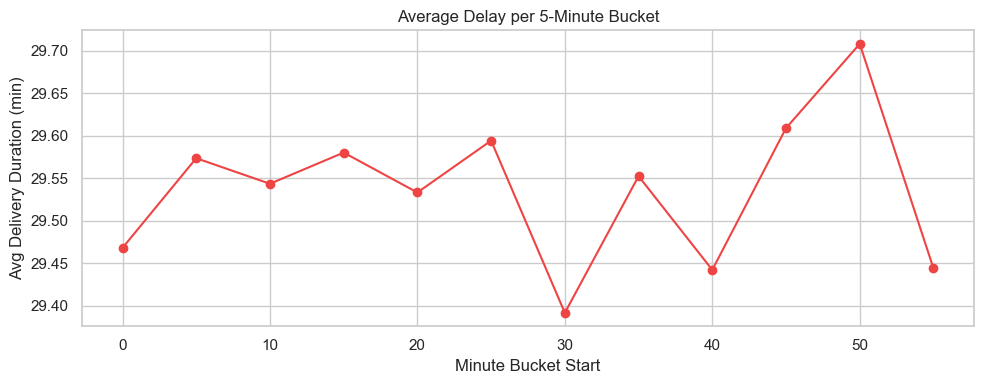

In [16]:
hourly_stats = (
    cleaned.groupby("order_hour", dropna=True)
    .agg(
        orders=("order_id", "count"),
        avg_delay_min=("delivery_duration_min", "mean"),
    )
    .dropna()
    .sort_index()
    .reset_index()
)

hourly_stats["order_hour"] = pd.to_numeric(hourly_stats["order_hour"], errors="coerce")
hourly_stats["avg_delay_min"] = pd.to_numeric(hourly_stats["avg_delay_min"], errors="coerce")
hourly_stats = hourly_stats.dropna(subset=["order_hour", "avg_delay_min"])

hourly_stats.head()

plt.figure(figsize=(10, 4))
sns.barplot(data=hourly_stats, x="order_hour", y="orders", color="#1d4ed8")
plt.title("Orders per Hour")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(hourly_stats["order_hour"], hourly_stats["avg_delay_min"], marker="o", color="#b91c1c")
plt.title("Average Delay per Hour")
plt.ylabel("Avg Delivery Duration (min)")
plt.tight_layout()
plt.show()

if not hourly_stats.empty:
    peak_hour = int(hourly_stats.loc[hourly_stats["avg_delay_min"].idxmax(), "order_hour"])
    print(f"Peak delays happen around {peak_hour:02d}:00")

if hourly_stats["order_hour"].nunique() <= 1 and "order_minute_of_day" in cleaned.columns:
    print("Note: source order time appears minute-second formatted, so hour-level spread is limited.")

    minute_bucket = (
        cleaned.assign(minute_bucket=(cleaned["order_minute_of_day"] // 5 * 5).astype("Int64"))
        .groupby("minute_bucket", dropna=True)
        .agg(
            orders=("order_id", "count"),
            avg_delay_min=("delivery_duration_min", "mean"),
        )
        .dropna()
        .reset_index()
    )

    plt.figure(figsize=(10, 4))
    sns.barplot(data=minute_bucket, x="minute_bucket", y="orders", color="#2563eb")
    plt.title("Orders per 5-Minute Bucket")
    plt.xlabel("Minute Bucket Start")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(minute_bucket["minute_bucket"], minute_bucket["avg_delay_min"], marker="o", color="#ef4444")
    plt.title("Average Delay per 5-Minute Bucket")
    plt.xlabel("Minute Bucket Start")
    plt.ylabel("Avg Delivery Duration (min)")
    plt.tight_layout()
    plt.show()

### Step 10
Product Category Analysis and Order Value vs Rating analysis for service quality segmentation.

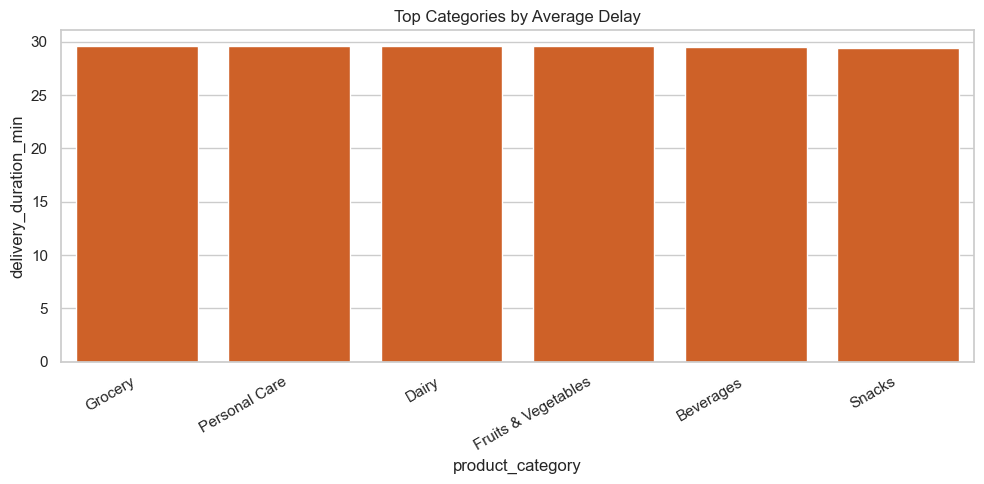

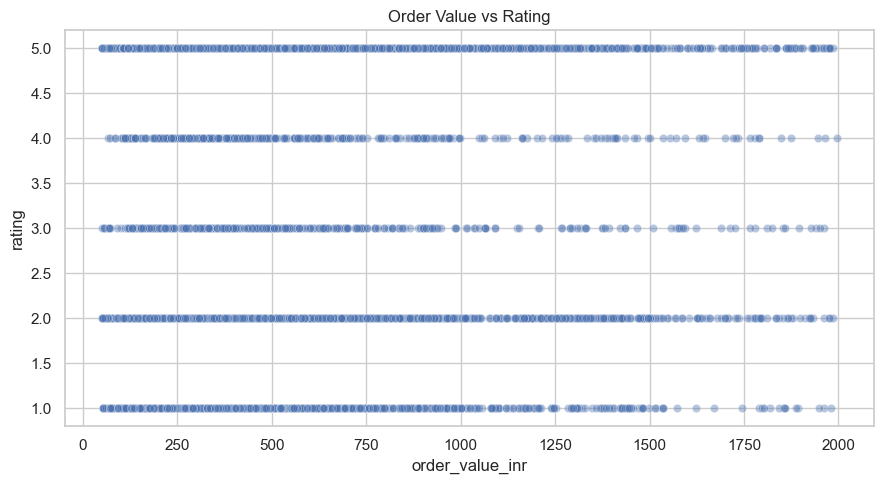

Category with highest delay: Grocery
Category with lowest rating: Grocery


In [12]:
category_stats = (
    cleaned.groupby("product_category", dropna=False)[["delivery_duration_min", "rating"]]
    .mean()
    .sort_values("delivery_duration_min", ascending=False)
)
category_stats.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=category_stats.reset_index().head(10),
    x="product_category",
    y="delivery_duration_min",
    color="#ea580c",
)
plt.title("Top Categories by Average Delay")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.scatterplot(x="order_value_inr", y="rating", data=cleaned.sample(min(5000, len(cleaned)), random_state=42), alpha=0.4)
plt.title("Order Value vs Rating")
plt.tight_layout()
plt.show()

print("Category with highest delay:", category_stats["delivery_duration_min"].idxmax())
print("Category with lowest rating:", category_stats["rating"].idxmin())

### Step 11
Refund Analysis extension: compare refund behavior across rating, delay category, and duration bands.

Refund rate overall (%): 45.82

Average rating by refund status:
refund_requested
No     4.571861
Yes    1.666798
Name: rating, dtype: float64

Refund rate by delay category (%):
delay_category
Late       45.941731
On-Time    45.713755
Name: refund_yes, dtype: float64

Late orders have 1.00x higher refund rate than On-Time orders


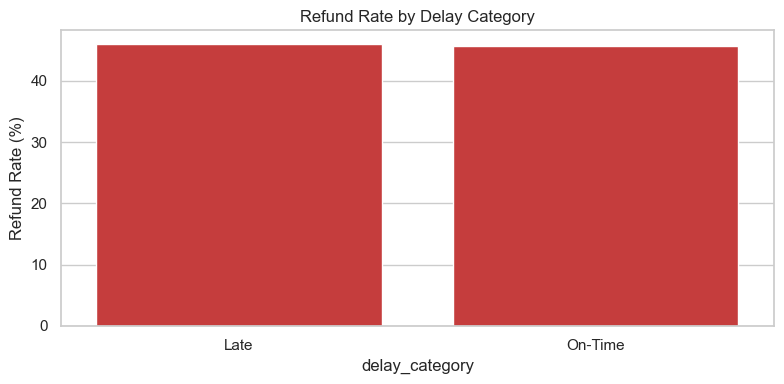

In [13]:
refund_df = cleaned.copy()
refund_df["refund_yes"] = refund_df["refund_requested"].eq("Yes").astype(int)

print("Refund rate overall (%):", round(refund_df["refund_yes"].mean() * 100, 2))

refund_vs_rating = refund_df.groupby("refund_requested")["rating"].mean()
print("\nAverage rating by refund status:")
print(refund_vs_rating)

refund_vs_delay = (
    refund_df.groupby("delay_category")["refund_yes"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
print("\nRefund rate by delay category (%):")
print(refund_vs_delay)

if "Late" in refund_vs_delay.index and "On-Time" in refund_vs_delay.index and refund_vs_delay["On-Time"] > 0:
    print(f"\nLate orders have {refund_vs_delay['Late']/refund_vs_delay['On-Time']:.2f}x higher refund rate than On-Time orders")

plt.figure(figsize=(8, 4))
sns.barplot(x=refund_vs_delay.index, y=refund_vs_delay.values, color="#dc2626")
plt.title("Refund Rate by Delay Category")
plt.ylabel("Refund Rate (%)")
plt.tight_layout()
plt.show()

### Step 12
Simple ML Model: baseline linear regression to predict rating using delivery duration.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

ml_df = cleaned[["delivery_duration_min", "rating"]].dropna()
X = ml_df[["delivery_duration_min"]]
y = ml_df["rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("LinearRegression baseline")
print("MAE:", round(mean_absolute_error(y_test, preds), 4))
print("R2:", round(r2_score(y_test, preds), 4))
print("Coefficient (rating change per +1 min delay):", round(float(model.coef_[0]), 4))

LinearRegression baseline
MAE: 1.4842
R2: -0.0001
Coefficient (rating change per +1 min delay): -0.0003


### Step 13
Business Recommendations:
- If delivery is expected to exceed 30 minutes, automatically send apology coupon communication.
- Prioritize high-delay product categories for operational fixes.
- Increase delivery partner availability during peak delay hours.
- Trigger fast support and retention workflows for high refund-risk segments.
- Use model predictions as an early warning for customer satisfaction drops.